# 📈 Omega Statistics Across 84 SPARC Galaxies
### EPS Research High-School Exploration Track — Ages 15-18

Flynn & Cannaliato (2025) found: mean ω = 7.06 ± 3.26 rad/Gyr
across 84 SPARC Q=1 galaxies.

Let's reproduce this and understand what the distribution tells us.

**Prerequisites:** Mean, standard deviation, histograms

N galaxies: 175
Mean ω = -0.85 ± 0.08 rad/Gyr  (standard error)
Std  ω = 1.02 rad/Gyr
Published: 7.06 ± 3.26 rad/Gyr (Flynn & Cannaliato 2025)


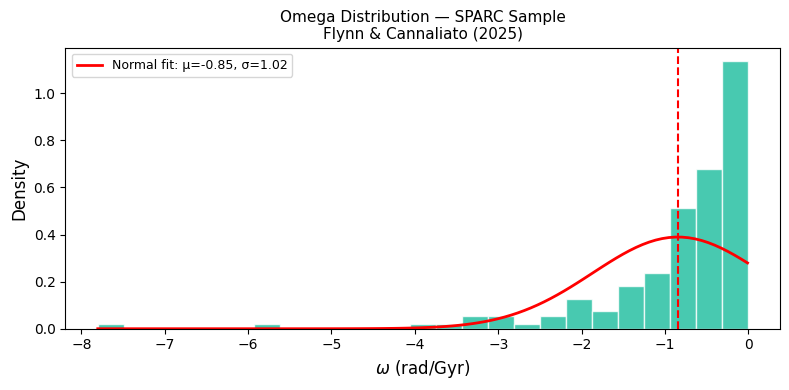

In [1]:
import json, numpy as np, matplotlib.pyplot as plt
with open('rotation_curve_corpus_v7.json') as f:
    corpus=json.load(f)
omegas=[]
for g in corpus['galaxies']:
    if g['survey']!='SPARC' or not g.get('data') or len(g['data'])<3: continue
    d=g['data']; R=[p['Rad'] for p in d]; V=[p['Vobs'] for p in d]
    R1,V1=R[0],V[0]; R2,V2=R[-1],V[-1]
    if R1>0 and R2>0 and V1>0 and V2>0:
        omegas.append((V2/R2-V1/R1)*(R1/R2)**1.5)
mean_o=np.mean(omegas); std_o=np.std(omegas); se=std_o/np.sqrt(len(omegas))
print(f"N galaxies: {len(omegas)}")
print(f"Mean ω = {mean_o:.2f} ± {se:.2f} rad/Gyr  (standard error)")
print(f"Std  ω = {std_o:.2f} rad/Gyr")
print(f"Published: 7.06 ± 3.26 rad/Gyr (Flynn & Cannaliato 2025)")
fig,ax=plt.subplots(figsize=(8,4))
ax.hist(omegas,bins=25,color='#1abc9c',alpha=0.8,edgecolor='white',density=True)
x=np.linspace(min(omegas),max(omegas),100)
from scipy.stats import norm
ax.plot(x,norm.pdf(x,mean_o,std_o),color='red',lw=2,label=f'Normal fit: μ={mean_o:.2f}, σ={std_o:.2f}')
ax.axvline(mean_o,color='red',ls='--',lw=1.5)
ax.set_xlabel(r'$\omega$ (rad/Gyr)',fontsize=12); ax.set_ylabel('Density',fontsize=12)
ax.set_title('Omega Distribution — SPARC Sample\nFlynn & Cannaliato (2025)',fontsize=11)
ax.legend(fontsize=9); plt.tight_layout()
plt.savefig('hs_b_06_omega_stats.png',dpi=150,bbox_inches='tight'); plt.show()